# Construction Site VLM Dataset - Data Preparation
Loads the raw dataset, explores it, computes stats, audits bounding boxes,
applies surgical fixes, and saves a cleaned copy for fine-tuning.

In [1]:
# from google.colab import drive
# drive.mount('/content/drive')

## Environment Setup

In [2]:
import os
import subprocess
import shutil

DRIVE_ROOT = "/content/drive/MyDrive/vlm-finetuning-project1"
REPO_DIR = "vlm-safety-reasoning"
ENV_PATH = f"{DRIVE_ROOT}/secrets/.env"


def load_secrets(env_path: str) -> dict:
    """Read a .env file and export its values into os.environ."""
    if not os.path.exists(env_path):
        raise FileNotFoundError(f"Secrets file not found at: {env_path}")

    secrets = {}
    with open(env_path, "r") as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith("#") or "=" not in line:
                continue
            key, value = line.split("=", 1)
            secrets[key] = value.strip(" \"'\r")
            os.environ[key] = secrets[key]
    return secrets


print(">>> Loading secrets...")
secrets = load_secrets(ENV_PATH)
required_keys = ["GIT_EMAIL", "GIT_NAME", "GITHUB_USERNAME", "GITHUB_TOKEN", "HF_TOKEN"]
missing = [k for k in required_keys if k not in secrets]
if missing:
    raise KeyError(f"Missing required secrets: {missing}")
print(">>> Secrets loaded successfully.")

print(">>> Configuring Git identity...")
subprocess.run(["git", "config", "--global", "user.email", secrets["GIT_EMAIL"]], check=True)
subprocess.run(["git", "config", "--global", "user.name", secrets["GIT_NAME"]], check=True)

AUTH_REPO_URL = (
    f"https://{secrets['GITHUB_USERNAME']}:{secrets['GITHUB_TOKEN']}"
    f"@github.com/epmresearch/vlm-safety-reasoning.git"
)

if os.path.exists(REPO_DIR):
    print(">>> Repo already present, pulling latest...")
    os.chdir(REPO_DIR)
    subprocess.run(["git", "remote", "set-url", "origin", AUTH_REPO_URL], check=True)
    subprocess.run(["git", "pull", "origin", "main"], check=True)
else:
    print(">>> Cloning repo...")
    subprocess.run(["git", "clone", AUTH_REPO_URL, REPO_DIR], check=True)
    os.chdir(REPO_DIR)

print(f">>> Working directory: {os.getcwd()}")

print(">>> Copying .env into local workspace...")
shutil.copy(ENV_PATH, ".env")

print(">>> Installing requirements...")
subprocess.run(["pip", "install", "-q", "-r", "requirements.txt"], check=True)
print(">>> Setup complete.")

>>> Loading secrets...
>>> Secrets loaded successfully.
>>> Configuring Git identity...
>>> Repo already present, pulling latest...
>>> Working directory: /content/vlm-safety-reasoning
>>> Copying .env into local workspace...
>>> Installing requirements...
>>> Setup complete.


## Imports & Configuration

In [3]:
from dotenv import load_dotenv
from huggingface_hub import login
from core.config import load_base_config
from core.io import get_drive_path
from data.loader import load_construction_dataset

import matplotlib.pyplot as plt
import matplotlib.patches as patches
import random
import textwrap
import json
import numpy as np
import pandas as pd
from collections import Counter
from tqdm.auto import tqdm

load_dotenv()
login(token=os.environ["HF_TOKEN"])

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


In [4]:
base_cfg = load_base_config()
print("drive_root:", base_cfg["drive_root"])
print("hf_repo:", base_cfg["dataset"]["hf_repo"])
print("raw cache path:", get_drive_path(base_cfg["dataset"]["raw_cache_subdir"]))

drive_root: /content/drive/MyDrive/vlm-finetuning-project1
hf_repo: LouisChen15/ConstructionSite
raw cache path: /content/drive/MyDrive/vlm-finetuning-project1/datasets/raw


In [5]:
dataset = load_construction_dataset()
print(dataset)

EXPECTED_COUNTS = {"train": 7009, "test": 3004}
for split, expected in EXPECTED_COUNTS.items():
    actual = len(dataset[split])
    status = "OK" if actual == expected else "MISMATCH"
    print(f"[{status}] {split}: expected {expected}, got {actual}")

2026-07-14 18:33:47 | INFO     | data.loader:load_construction_dataset:30 - Loading dataset 'LouisChen15/ConstructionSite' with cache_dir=/content/drive/MyDrive/vlm-finetuning-project1/datasets/raw
2026-07-14 18:33:49 | INFO     | data.loader:load_construction_dataset:34 - Train split size: 7009
2026-07-14 18:33:49 | INFO     | data.loader:load_construction_dataset:36 - Test split size: 3004
DatasetDict({
    train: Dataset({
        features: ['image', 'image_id', 'image_caption', 'illumination', 'camera_distance', 'view', 'quality_of_info', 'rule_1_violation', 'rule_2_violation', 'rule_3_violation', 'rule_4_violation', 'excavator', 'rebar', 'worker_with_white_hard_hat'],
        num_rows: 7009
    })
    test: Dataset({
        features: ['image', 'image_id', 'image_caption', 'illumination', 'camera_distance', 'view', 'quality_of_info', 'rule_1_violation', 'rule_2_violation', 'rule_3_violation', 'rule_4_violation', 'excavator', 'rebar', 'worker_with_white_hard_hat'],
        num_rows

## Visualization Utility

A single, reusable `plot_sample` function used throughout the notebook.
Handles both object boxes and rule-violation boxes.

In [6]:
def _normalize_boxes(boxes):
    """Ensure boxes is a list of [xmin, ymin, xmax, ymax] lists."""
    if not boxes:
        return []
    if isinstance(boxes[0], (int, float)):
        return [boxes]
    return boxes


def plot_sample(sample, show_objects=True, show_violations=True, verbose=True):
    img = sample["image"]
    width, height = img.size

    fig, ax = plt.subplots(1, figsize=(10, 8))
    ax.imshow(img)
    ax.axis("off")

    if verbose:
        print("=== METADATA ===")
        print(f"ID: {sample['image_id']} | Illumination: {sample['illumination']} "
              f"| View: {sample['view']} | Distance: {sample['camera_distance']}")
        print("\n=== CAPTION ===")
        print(textwrap.fill(sample["image_caption"], width=100))
        print("-" * 100)

    def draw_boxes(boxes, color, label):
        for box in _normalize_boxes(boxes):
            xmin, ymin, xmax, ymax = box
            xmin_px, xmax_px = xmin * width, xmax * width
            ymin_px, ymax_px = ymin * height, ymax * height
            box_width = xmax_px - xmin_px
            box_height = ymax_px - ymin_px

            # Degenerate box (zero/near-zero width or height) -> draw as a red line instead
            if box_width <= 0.1 or box_height <= 0.1:
                ax.plot([xmin_px, xmax_px], [ymin_px, ymax_px],
                        color="red", marker="o", markersize=10, linewidth=2)
                ax.text(xmin_px, ymin_px - 8, f"BROKEN (Line): {label}", color="white",
                        fontsize=10, fontweight="bold",
                        bbox=dict(facecolor="red", alpha=0.9, edgecolor="none", pad=2))
                continue

            rect = patches.Rectangle(
                (xmin_px, ymin_px), box_width, box_height,
                linewidth=2, edgecolor=color, facecolor="none"
            )
            ax.add_patch(rect)
            ax.text(xmin_px, ymin_px - 5, label, color="white", fontsize=10,
                    bbox=dict(facecolor=color, alpha=0.8, edgecolor="none", pad=1))

    if show_objects:
        draw_boxes(sample.get("excavator", []), "blue", "Excavator")
        draw_boxes(sample.get("rebar", []), "orange", "Rebar")
        draw_boxes(sample.get("worker_with_white_hard_hat", []), "green", "White Hard Hat")

    if show_violations:
        for rule_idx in range(1, 5):
            violation = sample.get(f"rule_{rule_idx}_violation")
            if violation and violation.get("bounding_box"):
                if verbose:
                    print(f"\n[!] RULE {rule_idx} VIOLATION:")
                    print(textwrap.fill(violation["reason"], width=100))
                draw_boxes(violation["bounding_box"], "red", f"Rule {rule_idx} Violation")

    plt.tight_layout()
    plt.show()

## Exploratory Visualization

In [7]:
def find_one_example_each(split):
    """Scan a split once and return the first sample found for each
    rule violation and each object type."""
    targets = {
        "rule_1_violation": None, "rule_2_violation": None,
        "rule_3_violation": None, "rule_4_violation": None,
        "excavator": None, "rebar": None, "worker_with_white_hard_hat": None,
    }

    for sample in split:
        for key in list(targets.keys()):
            if targets[key] is None and sample.get(key):
                targets[key] = sample
        if all(targets.values()):
            print("Found all required examples! Stopping search early.")
            break

    return targets


print("Searching for one example of each category...")
examples = find_one_example_each(dataset["train"])

for i in range(1, 5):
    key = f"rule_{i}_violation"
    if examples[key]:
        plot_sample(examples[key], show_objects=False, show_violations=True)
    else:
        print(f"No Rule {i} violations found in this scan.")

for key, label in [("excavator", "Excavator"), ("rebar", "Rebar"),
                    ("worker_with_white_hard_hat", "White Hard Hat")]:
    if examples[key]:
        plot_sample(examples[key], show_objects=True, show_violations=False)
    else:
        print(f"No {label} found in this scan.")

Output hidden; open in https://colab.research.google.com to view.

=== METADATA ===
ID: 0004900 | Illumination: night | View: elevation view | Distance: short distance

=== CAPTION ===
The image shows two workers with hard hats on a construction site at night. The worker on the left
is stepping on a wooden board. The worker on the right is holding a tool and interacting with the
material. Both are standing on a concrete surface, with a light pole behind them.
----------------------------------------------------------------------------------------------------

[!] RULE 1 VIOLATION:
The two workers do not have high-visibility retroreflective vests when working at night.


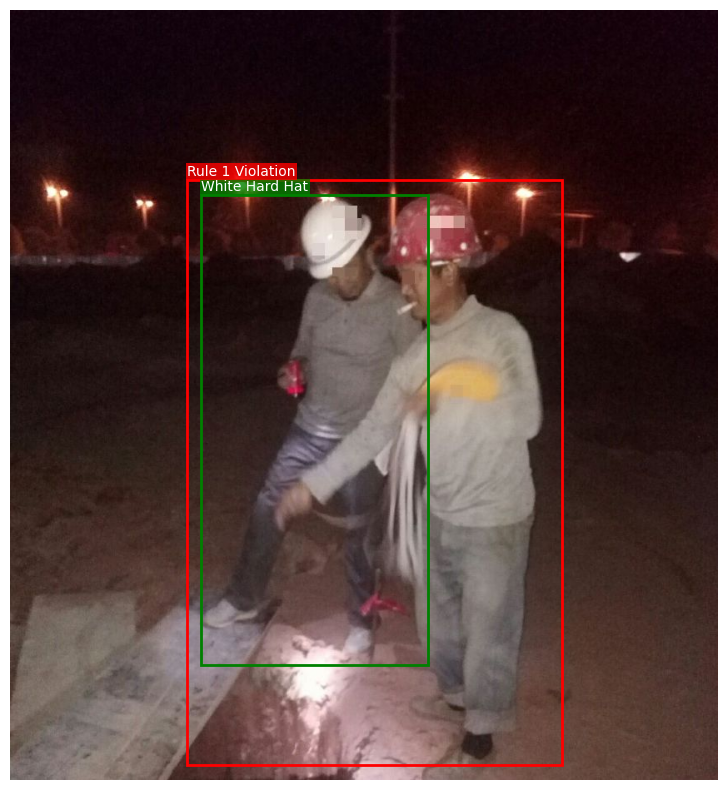

In [8]:
night_sample = next(
    (s for s in dataset["train"] if s["illumination"] == "night"), None
)

if night_sample:
    plot_sample(night_sample)
else:
    print("No night images found in this scan.")

## Dataset Statistics

In [9]:
def extract_and_save_stats(split_data, split_name, save_directory):
    print(f"Crunching statistics for the {split_name.upper()} split...")

    stats = {
        "Illumination": Counter(), "Camera Distance": Counter(),
        "View": Counter(), "Quality of Info": Counter(),
        "Rule Violations": Counter(), "Object Presence": Counter(),
    }

    for sample in tqdm(split_data, desc=f"{split_name.capitalize()} Progress"):
        stats["Illumination"][sample["illumination"]] += 1
        stats["Camera Distance"][sample["camera_distance"]] += 1
        stats["View"][sample["view"]] += 1
        stats["Quality of Info"][sample["quality_of_info"]] += 1

        rule_labels = {1: "Rule 1 (PPE)", 2: "Rule 2 (Harness)",
                        3: "Rule 3 (Edge Protection)", 4: "Rule 4 (Blind Spot)"}
        for i, label in rule_labels.items():
            if sample[f"rule_{i}_violation"]:
                stats["Rule Violations"][label] += 1

        if sample["excavator"]:
            stats["Object Presence"]["Excavator"] += 1
        if sample["rebar"]:
            stats["Object Presence"]["Rebar"] += 1
        if sample["worker_with_white_hard_hat"]:
            stats["Object Presence"]["White Hard Hat"] += 1

    flat_data = [
        {"Category": category, "Attribute": str(attribute), "Count": count}
        for category, counter in stats.items()
        for attribute, count in counter.items()
    ]

    df_stats = pd.DataFrame(flat_data).sort_values(
        by=["Category", "Count"], ascending=[True, False]
    ).reset_index(drop=True)

    print(f"\n--- {split_name.upper()} SPLIT STATISTICS ---")
    display(df_stats)

    os.makedirs(save_directory, exist_ok=True)
    out_path = os.path.join(save_directory, f"construction_site_{split_name}_stats.csv")
    df_stats.to_csv(out_path, index=False)
    print(f"[{split_name.upper()}] Statistics saved to:\n{out_path}\n")

    return df_stats


STATS_SAVE_DIR = "/content/drive/MyDrive/vlm-finetuning-project1/datasets/stats"
df_train_stats = extract_and_save_stats(dataset["train"], "train", STATS_SAVE_DIR)
df_test_stats = extract_and_save_stats(dataset["test"], "test", STATS_SAVE_DIR)

Crunching statistics for the TRAIN split...


Train Progress:   0%|          | 0/7009 [00:00<?, ?it/s]


--- TRAIN SPLIT STATISTICS ---


,Category,Attribute,Count
0,Camera Distance,mid distance,5063
1,Camera Distance,short distance,1560
2,Camera Distance,long distance,386
3,Illumination,normal lighting,5885
4,Illumination,underexposed,692
5,Illumination,overexposed,273
6,Illumination,night,159
7,Object Presence,Excavator,2415
8,Object Presence,Rebar,846
9,Object Presence,White Hard Hat,680


[TRAIN] Statistics saved to:
/content/drive/MyDrive/vlm-finetuning-project1/datasets/stats/construction_site_train_stats.csv

Crunching statistics for the TEST split...


Test Progress:   0%|          | 0/3004 [00:00<?, ?it/s]


--- TEST SPLIT STATISTICS ---


,Category,Attribute,Count
0,Camera Distance,short distance,1360
1,Camera Distance,mid distance,1309
2,Camera Distance,long distance,334
3,Camera Distance,None,1
4,Illumination,normal lighting,2426
5,Illumination,underexposed,381
6,Illumination,overexposed,154
7,Illumination,night,43
8,Object Presence,Excavator,1080
9,Object Presence,Rebar,327


[TEST] Statistics saved to:
/content/drive/MyDrive/vlm-finetuning-project1/datasets/stats/construction_site_test_stats.csv



3,	Camera Distance,	None,	1

## Co-occurrence Analysis & Cross-check vs Paper

In [10]:
def compute_cooccurrence(split, split_name):
    n = len(split)
    rule_flags = {f"rule_{i}": [] for i in range(1, 5)}
    obj_flags = {"excavator": [], "rebar": [], "white_hard_hat": []}

    for sample in split:
        for i in range(1, 5):
            rule_flags[f"rule_{i}"].append(1 if sample[f"rule_{i}_violation"] else 0)
        obj_flags["excavator"].append(1 if sample["excavator"] else 0)
        obj_flags["rebar"].append(1 if sample["rebar"] else 0)
        obj_flags["white_hard_hat"].append(1 if sample["worker_with_white_hard_hat"] else 0)

    df_rules = pd.DataFrame(rule_flags)
    df_objs = pd.DataFrame(obj_flags)

    rate_summary = pd.concat([
        df_rules.mean().rename("rate") * 100,
        df_objs.mean().rename("rate") * 100,
    ]).to_frame()
    rate_summary["count"] = pd.concat([df_rules.sum(), df_objs.sum()]).astype(int)
    rate_summary["split"] = split_name
    rate_summary["n_images"] = n

    return rate_summary, df_rules, df_objs


train_rates, train_rules, train_objs = compute_cooccurrence(dataset["train"], "train")
test_rates, test_rules, test_objs = compute_cooccurrence(dataset["test"], "test")

print("=== Rate Summary (Train) ===")
display(train_rates)
print("\n=== Rate Summary (Test) ===")
display(test_rates)

=== Rate Summary (Train) ===


,rate,count,split,n_images
rule_1,9.659010,677,train,7009
rule_2,0.841775,59,train,7009
rule_3,1.555143,109,train,7009
rule_4,0.656299,46,train,7009
excavator,34.455700,2415,train,7009
rebar,12.070195,846,train,7009
white_hard_hat,9.701812,680,train,7009



=== Rate Summary (Test) ===


,rate,count,split,n_images
rule_1,10.785619,324,test,3004
rule_2,0.832224,25,test,3004
rule_3,2.097204,63,test,3004
rule_4,0.798935,24,test,3004
excavator,35.952064,1080,test,3004
rebar,10.885486,327,test,3004
white_hard_hat,10.452730,314,test,3004


In [11]:
paper_train_counts = {
    "rule_1": 677, "rule_2": 59, "rule_3": 109, "rule_4": 46,
    "excavator": 2415, "rebar": 846, "white_hard_hat": 680,
}
paper_test_counts = {
    "rule_1": 323, "rule_2": 25, "rule_3": 63, "rule_4": 24,
    "excavator": 1080, "rebar": 327, "white_hard_hat": 314,
}


def cross_check(rates_df, paper_counts, split_label):
    print(f"\n=== Cross-check vs Paper Table 4 ({split_label} Split) ===")
    for k, expected in paper_counts.items():
        actual = rates_df.loc[k, "count"] if k in rates_df.index else None
        status = "MATCH" if actual == expected else "MISMATCH"
        print(f"{k.ljust(15)} | Paper: {str(expected).ljust(4)} | Computed: {str(actual).ljust(4)} | {status}")


cross_check(train_rates, paper_train_counts, "Train")
cross_check(test_rates, paper_test_counts, "Test")


=== Cross-check vs Paper Table 4 (Train Split) ===
rule_1          | Paper: 677  | Computed: 677  | MATCH
rule_2          | Paper: 59   | Computed: 59   | MATCH
rule_3          | Paper: 109  | Computed: 109  | MATCH
rule_4          | Paper: 46   | Computed: 46   | MATCH
excavator       | Paper: 2415 | Computed: 2415 | MATCH
rebar           | Paper: 846  | Computed: 846  | MATCH
white_hard_hat  | Paper: 680  | Computed: 680  | MATCH

=== Cross-check vs Paper Table 4 (Test Split) ===
rule_1          | Paper: 323  | Computed: 324  | MISMATCH
rule_2          | Paper: 25   | Computed: 25   | MATCH
rule_3          | Paper: 63   | Computed: 63   | MATCH
rule_4          | Paper: 24   | Computed: 24   | MATCH
excavator       | Paper: 1080 | Computed: 1080 | MATCH
rebar           | Paper: 327  | Computed: 327  | MATCH
white_hard_hat  | Paper: 314  | Computed: 314  | MATCH


rule_1          | Paper: 323  | Computed: 324  | MISMATCH

In [12]:
save_dir = "/content/drive/MyDrive/vlm-finetuning-project1/datasets/stats"
os.makedirs(save_dir, exist_ok=True)

train_rates.to_csv(f"{save_dir}/cooccurrence_rates_train.csv")
test_rates.to_csv(f"{save_dir}/cooccurrence_rates_test.csv")

train_rule_matrix = train_rules.T.dot(train_rules)
train_obj_matrix = train_objs.T.dot(train_objs)
test_rule_matrix = test_rules.T.dot(test_rules)
test_obj_matrix = test_objs.T.dot(test_objs)

print("=== Train Rule Co-occurrence Matrix ===")
display(train_rule_matrix)
print("=== Train Object Co-occurrence Matrix ===")
display(train_obj_matrix)

train_rule_matrix.to_csv(f"{save_dir}/rule_cooc_matrix_train.csv")
train_obj_matrix.to_csv(f"{save_dir}/obj_cooc_matrix_train.csv")
test_rule_matrix.to_csv(f"{save_dir}/rule_cooc_matrix_test.csv")
test_obj_matrix.to_csv(f"{save_dir}/obj_cooc_matrix_test.csv")

print(f"\nSaved co-occurrence stats to {save_dir}")

=== Train Rule Co-occurrence Matrix ===


,rule_1,rule_2,rule_3,rule_4
rule_1,677,6,7,11
rule_2,6,59,0,0
rule_3,7,0,109,1
rule_4,11,0,1,46


=== Train Object Co-occurrence Matrix ===


,excavator,rebar,white_hard_hat
excavator,2415,135,219
rebar,135,846,97
white_hard_hat,219,97,680



Saved co-occurrence stats to /content/drive/MyDrive/vlm-finetuning-project1/datasets/stats


## Bounding Box

In [13]:
def validate_box(box, tol=1e-6):
    xmin, ymin, xmax, ymax = box
    issues = []

    if not all(0 - tol <= c <= 1 + tol for c in box):
        issues.append("out_of_range")
    if xmin >= xmax - tol:
        issues.append("invalid_x_order_or_zero_width")
    if ymin >= ymax - tol:
        issues.append("invalid_y_order_or_zero_height")

    area = max(0, xmax - xmin) * max(0, ymax - ymin)
    if area < 1e-5:
        issues.append("near_zero_area")

    return issues, area


def audit_boxes(split, split_name):
    records = []
    for sample in split:
        image_id = sample["image_id"]

        objects_to_check = {
            "excavator": sample.get("excavator", []),
            "rebar": sample.get("rebar", []),
            "white_hard_hat": sample.get("worker_with_white_hard_hat", []),
        }
        for cls_name, boxes in objects_to_check.items():
            for box in boxes:
                issues, area = validate_box(box)
                records.append({
                    "split": split_name, "image_id": image_id, "class": cls_name,
                    "box": box, "area": area,
                    "issues": ";".join(issues) if issues else "ok",
                })

        for i in range(1, 5):
            v = sample.get(f"rule_{i}_violation")
            if v is None:
                continue
            boxes = v.get("bounding_box")
            if not boxes:
                records.append({
                    "split": split_name, "image_id": image_id,
                    "class": f"rule_{i}_violation",
                    "box": [], "area": 0.0, "issues": "missing_box",
                })
            else:
                for box in boxes:
                    issues, area = validate_box(box)
                    records.append({
                        "split": split_name, "image_id": image_id,
                        "class": f"rule_{i}_violation",
                        "box": box, "area": area,
                        "issues": ";".join(issues) if issues else "ok",
                    })

    return pd.DataFrame(records)

In [14]:
df_boxes_train = audit_boxes(dataset["train"], "train")
df_boxes_test = audit_boxes(dataset["test"], "test")
df_boxes_all = pd.concat([df_boxes_train, df_boxes_test], ignore_index=True)

invalid_boxes = df_boxes_all[df_boxes_all["issues"] != "ok"].copy()

print(f"\n=== Invalid or Missing Boxes Found: {len(invalid_boxes)} ===")
display(invalid_boxes.groupby(["split", "class", "issues"]).size().unstack(fill_value=0))

invalid_boxes.to_csv(f"{save_dir}/bbox_invalid_flagged.csv", index=False)


=== Invalid or Missing Boxes Found: 6 ===


issues                  invalid_x_order_or_zero_width;near_zero_area  \
split class                                                            
test  rule_1_violation                                             0   
train excavator                                                    0   
      rebar                                                        0   
      rule_1_violation                                             1   
      white_hard_hat                                               1   

issues                  invalid_y_order_or_zero_height;near_zero_area  \
split class                                                             
test  rule_1_violation                                              0   
train excavator                                                     1   
      rebar                                                         1   
      rule_1_violation                                              0   
      white_hard_hat                                                0   

issues                  missing_box  
split class                          
test  rule_1_violation            1  
train excavator                   0  
      rebar                       0  
      rule_1_violation            1  
      white_hard_hat              0

In [15]:
invalid_boxes

,split,image_id,class,box,area,issues
123,train,0005014,rule_1_violation,"[0.68, 0.19, 0.68, 0.2]",0.0,invalid_x_order_or_zero_width;near_zero_area
1755,train,0006857,white_hard_hat,"[0.95, 0.45, 0.95, 0.46]",0.0,invalid_x_order_or_zero_width;near_zero_area
4285,train,0009782,rule_1_violation,[],0.0,missing_box
5918,train,0011654,excavator,"[0.93, 0.95, 0.94, 0.95]",0.0,invalid_y_order_or_zero_height;near_zero_area
7381,train,0013188,rebar,"[0.9, 0.43, 0.91, 0.43]",0.0,invalid_y_order_or_zero_height;near_zero_area
8341,test,0000167,rule_1_violation,[],0.0,missing_box


## Inspect Flagged Boxes

In [16]:
def find_sample_by_image_id(split, image_id):
    for sample in split:
        if str(sample["image_id"]) == str(image_id):
            return sample
    return None


def plot_degenerate_box(sample, box, class_name, zoom_pad=0.08):
    img = sample["image"]
    width, height = img.size
    xmin, ymin, xmax, ymax = box

    xmin_px, xmax_px = xmin * width, xmax * width
    ymin_px, ymax_px = ymin * height, ymax * height

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    axes[0].imshow(img)
    axes[0].set_title(f"Full image | {class_name} | id={sample['image_id']}")
    axes[0].axis("off")
    axes[0].plot([xmin_px, xmax_px], [ymin_px, ymax_px], color="red",
                 linewidth=3, marker="o", markersize=6)

    pad_x, pad_y = zoom_pad * width, zoom_pad * height
    axes[1].imshow(img)
    axes[1].set_xlim(max(0, xmin_px - pad_x), min(width, xmax_px + pad_x))
    axes[1].set_ylim(min(height, ymax_px + pad_y), max(0, ymin_px - pad_y))
    axes[1].plot([xmin_px, xmax_px], [ymin_px, ymax_px], color="red",
                 linewidth=3, marker="o", markersize=8)
    axes[1].set_title("Zoomed crop (degenerate box highlighted)")
    axes[1].axis("off")

    plt.tight_layout()
    plt.show()

In [17]:
for _, row in invalid_boxes.iterrows():
    split_data = dataset["train"] if row["split"] == "train" else dataset["test"]
    sample = find_sample_by_image_id(split_data, row["image_id"])

    print(f"\n{'='*80}")
    print(f"Split: {row['split'].upper()} | Image ID: {row['image_id']} "
          f"| Class: {row['class']} | Issue: {row['issues']}")

    if row["issues"] == "missing_box":
        v = sample.get(row["class"])
        reason_text = v.get("reason", "No reason provided") if v else "No reason provided"
        print(f"ACTION NEEDED: Box is missing. Annotator's reason: \"{reason_text}\"")
        print("Manually add coordinates for this image.")
    else:
        print(f"ACTION NEEDED: Box geometry is broken. Raw coordinates: {row['box']}")
        plot_degenerate_box(sample, row["box"], row["class"])

Output hidden; open in https://colab.research.google.com to view.

## Targeted Inspection of Known Problems

In [18]:
targets = {
    "train": ["0005014", "5014", "0006857", "6857", "0009782", "9782",
              "0011654", "11654", "0013188", "13188"],
    "test": ["0000167", "167"],
}

for split_name, ids_to_find in targets.items():
    print(f"Scanning {split_name.upper()} split...")
    found = 0

    for sample in dataset[split_name]:
        if str(sample["image_id"]) not in ids_to_find:
            continue

        print(f"\n{'='*80}\n  INSPECTING SAMPLE | Split: {split_name.upper()} "
              f"| ID: {sample['image_id']}\n{'='*80}")

        sample_dict = dict(sample)
        sample_dict["image"] = "<PIL Image Object Removed for JSON Printing>"
        print("\n--- RAW JSON DATA ---")
        print(json.dumps(sample_dict, indent=4))

        for i in range(1, 5):
            v = sample.get(f"rule_{i}_violation")
            if v and not v.get("bounding_box"):
                print(f"\n  WARNING: Rule {i} has a text reason but NO BOUNDING BOX ([])!")

        print("\n--- VISUALIZATION ---")
        plot_sample(sample, verbose=False)

        found += 1
        if (split_name == "train" and found == 5) or (split_name == "test" and found == 1):
            break

Output hidden; open in https://colab.research.google.com to view.

## Find & Fix Missing Attribute Values

The TEST split stats showed `Camera Distance: None: 1` — one sample is
missing this attribute.

In [19]:
# Scan all four categorical attributes across both splits for None/missing values
attr_fields = ["illumination", "camera_distance", "view", "quality_of_info"]

missing_attr_records = []
for split_name in ["train", "test"]:
    for sample in dataset[split_name]:
        for field in attr_fields:
            if sample.get(field) is None:
                missing_attr_records.append({
                    "split": split_name,
                    "image_id": sample["image_id"],
                    "field": field,
                })

df_missing_attrs = pd.DataFrame(missing_attr_records)
print(f"Found {len(df_missing_attrs)} missing attribute value(s):")
display(df_missing_attrs)

Found 1 missing attribute value(s):


,split,image_id,field
0,test,0000388,camera_distance



Split: TEST | Image ID: 0000388 | Missing field: camera_distance
Current values -> illumination: normal lighting | camera_distance: None | view: plan view | quality_of_info: poor info


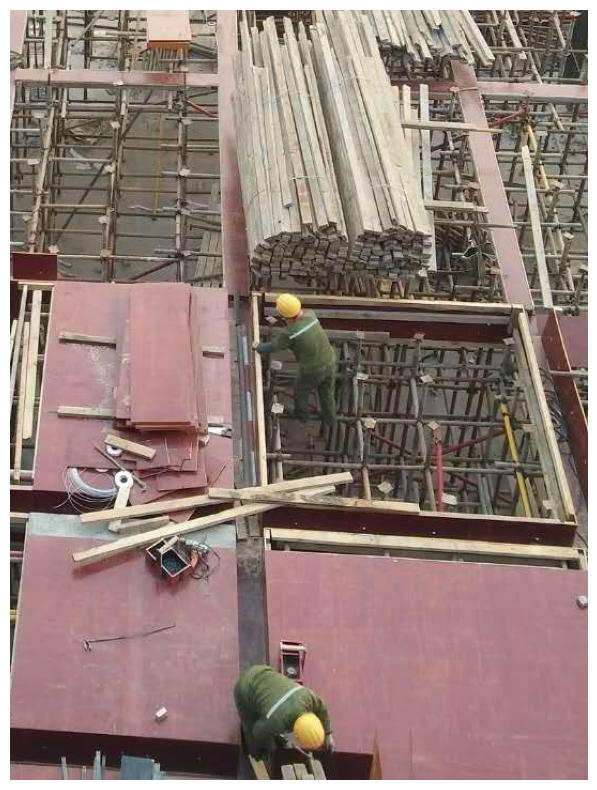

In [20]:
# Inspect each flagged sample so we can visually determine the correct value
for _, row in df_missing_attrs.iterrows():
    sample = find_sample_by_image_id(dataset[row["split"]], row["image_id"])
    print(f"\n{'='*80}")
    print(f"Split: {row['split'].upper()} | Image ID: {row['image_id']} | Missing field: {row['field']}")
    print(f"Current values -> illumination: {sample['illumination']} | "
          f"camera_distance: {sample['camera_distance']} | "
          f"view: {sample['view']} | quality_of_info: {sample['quality_of_info']}")
    plot_sample(sample, show_objects=False, show_violations=False, verbose=False)

## Bounding Box Calibration

Hand-pick the replacement box for image `0009782`.

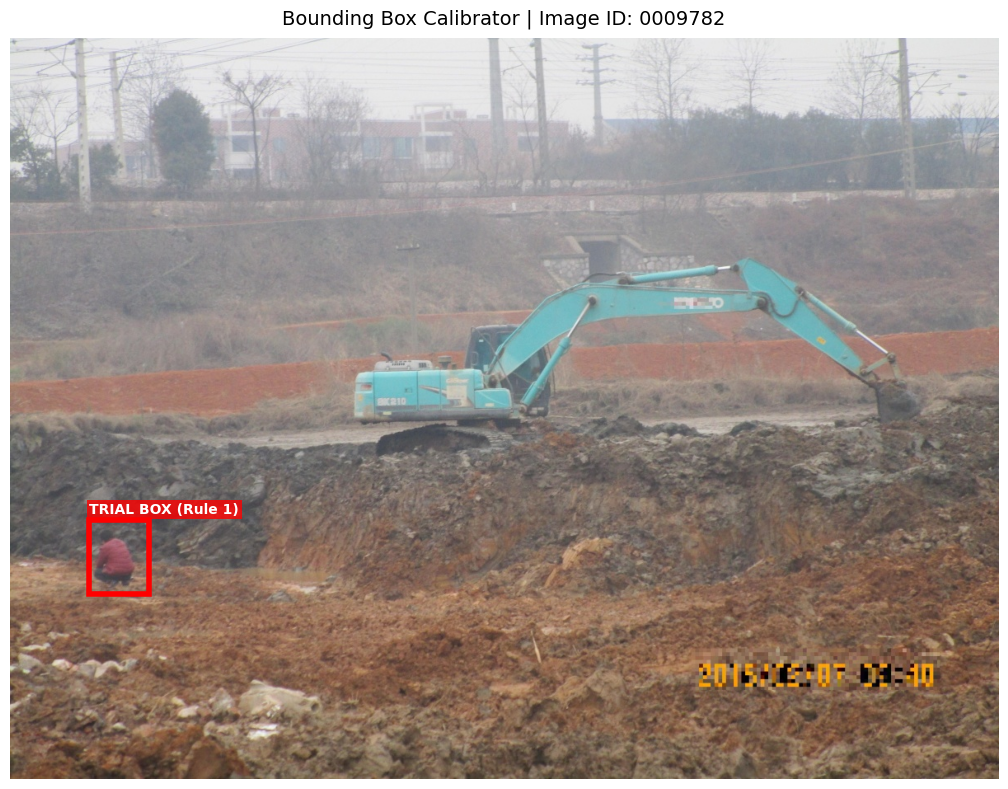

Current Trial Coordinates: [0.08, 0.65, 0.14, 0.75]


In [21]:
# Format: [xmin, ymin, xmax, ymax], normalized 0.0-1.0
TRIAL_BOX = [0.08, 0.65, 0.14, 0.75]
target_id = "0009782"

sample = next((s for s in dataset["train"] if str(s["image_id"]) == target_id), None)

if sample is None:
    print(f"Error: Could not find Image ID {target_id} in the train split.")
else:
    img = sample["image"]
    width, height = img.size

    fig, ax = plt.subplots(1, figsize=(12, 8))
    ax.imshow(img)
    ax.axis("off")

    xmin, ymin, xmax, ymax = TRIAL_BOX
    xmin_px, ymin_px = xmin * width, ymin * height
    box_width, box_height = (xmax - xmin) * width, (ymax - ymin) * height

    rect = patches.Rectangle((xmin_px, ymin_px), box_width, box_height,
                              linewidth=4, edgecolor="red", facecolor="none")
    ax.add_patch(rect)
    ax.text(xmin_px, ymin_px - 8, "TRIAL BOX (Rule 1)", color="white", fontweight="bold",
            bbox=dict(facecolor="red", alpha=0.8, edgecolor="none", pad=2))

    plt.title(f"Bounding Box Calibrator | Image ID: {target_id}", fontsize=14, pad=10)
    plt.tight_layout()
    plt.show()

    print(f"Current Trial Coordinates: {TRIAL_BOX}")

## Apply Fixes

In [22]:
def fix_annotations(sample):
    img_id = str(sample["image_id"])

    # --- TRAIN SPLIT FIXES ---
    if img_id in ["0005014", "5014"]:
        if sample["rule_1_violation"]:
            sample["rule_1_violation"]["bounding_box"] = [
                b for b in sample["rule_1_violation"]["bounding_box"]
                if b != [0.68, 0.19, 0.68, 0.2]
            ]

    elif img_id in ["0006857", "6857"]:
        sample["worker_with_white_hard_hat"] = [
            b for b in sample["worker_with_white_hard_hat"]
            if b != [0.95, 0.45, 0.95, 0.46]
        ]

    elif img_id in ["0011654", "11654"]:
        sample["excavator"] = [
            b for b in sample["excavator"]
            if b != [0.93, 0.95, 0.94, 0.95]
        ]

    elif img_id in ["0013188", "13188"]:
        sample["rebar"] = [
            b for b in sample["rebar"]
            if b != [0.9, 0.43, 0.91, 0.43]
        ]

    elif img_id in ["0009782", "9782"]:
        if sample["rule_1_violation"]:
            sample["rule_1_violation"]["bounding_box"] = [[0.08, 0.65, 0.14, 0.75]]

    # --- TEST SPLIT FIXES ---
    elif img_id in ["0000167", "167"]:
        sample["rule_1_violation"] = None

    # --- MISSING ATTRIBUTE FIX ---
    elif img_id in ["0000388", "388"]:
        sample["camera_distance"] = "mid distance"  # observed value

    return sample

In [23]:
print("Applying surgical fixes to the dataset annotations...")
dataset["train"] = dataset["train"].map(fix_annotations)
dataset["test"] = dataset["test"].map(fix_annotations)
print("Fixes applied successfully!")

Applying surgical fixes to the dataset annotations...


Map:   0%|          | 0/7009 [00:00<?, ? examples/s]

Map:   0%|          | 0/3004 [00:00<?, ? examples/s]

Fixes applied successfully!


## Save Cleaned Dataset

Saved under a **new** path (`raw_cleaned`, not `raw`).

In [24]:
CLEANED_DATASET_PATH = "/content/drive/MyDrive/vlm-finetuning-project1/datasets/raw_cleaned"

os.makedirs(CLEANED_DATASET_PATH, exist_ok=True)
print(f"\nSaving fully cleaned dataset to {CLEANED_DATASET_PATH}...")
dataset.save_to_disk(CLEANED_DATASET_PATH)
print("Done.")


Saving fully cleaned dataset to /content/drive/MyDrive/vlm-finetuning-project1/datasets/raw_cleaned...


Saving the dataset (0/7 shards):   0%|          | 0/7009 [00:00<?, ? examples/s]

Saving the dataset (0/3 shards):   0%|          | 0/3004 [00:00<?, ? examples/s]

Done.


In [25]:
from datasets import load_from_disk

check_ds = load_from_disk("/content/drive/MyDrive/vlm-finetuning-project1/datasets/raw_cleaned")
print(check_ds)

# Confirm one of the fixes is actually present
sample = next(s for s in check_ds["test"] if str(s["image_id"]) in ["0000167", "167"])
print("rule_1_violation for 0000167 (should be None):", sample["rule_1_violation"])

DatasetDict({
    train: Dataset({
        features: ['image', 'image_id', 'image_caption', 'illumination', 'camera_distance', 'view', 'quality_of_info', 'rule_1_violation', 'rule_2_violation', 'rule_3_violation', 'rule_4_violation', 'excavator', 'rebar', 'worker_with_white_hard_hat'],
        num_rows: 7009
    })
    test: Dataset({
        features: ['image', 'image_id', 'image_caption', 'illumination', 'camera_distance', 'view', 'quality_of_info', 'rule_1_violation', 'rule_2_violation', 'rule_3_violation', 'rule_4_violation', 'excavator', 'rebar', 'worker_with_white_hard_hat'],
        num_rows: 3004
    })
})
rule_1_violation for 0000167 (should be None): None
